# TP4 : Factorisation en matrices non-négatives (NMF)

Importez les bibliothèques suivantes.

In [2]:
import numpy as np
import pandas as pd
import math
import matplotlib.pyplot as plt

Les TPs précédents portaient sur le K-clustering et la PCA. Le présent TP utilisant les résultats de ces dernier, voici une cellule important les classes `KMeans` (**[documentation](https://scikit-learn.org/stable/modules/generated/sklearn.cluster.KMeans.html)**) et `PCA` (**[documentation](https://scikit-learn.org/stable/modules/generated/sklearn.decomposition.PCA.html)**) de la bibliothèque `sklearn`. Regardez bien les documentations. Le nom des attributs et méthodes n'est pas nécessairement le même que dans les classes que nous avons nous même définies. 

In [31]:
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA

def accuracy(labels):
    ct = pd.crosstab(labels, y)
    row_maxes = ct.max(axis=1)
    sum_of_maxes = row_maxes.sum()
    total_elements = ct.values.sum()
    proportion = sum_of_maxes / total_elements
    return proportion

Nous avons également besoin de la fonction affichant une image ou une liste d'images (au format 784 pixels).

In [32]:
def display_image(source):
    if len(source) == 784:
        images = [source]
    elif len(source[0]) == 784:
        images = source
    else:
        print("error")
    
    l = len(images)
    c = math.ceil(l / 3)
    fig, axes = plt.subplots(c, 3, figsize=(12, 5))

    for i, ax in enumerate(axes.flat):
        if i < l:
            img = images[i].reshape(28, 28)
            ax.imshow(img, cmap='gray')
            ax.set_title(f"Image {i + 1}")
        ax.axis('off')

Enfin, importez les jeux de données.

In [6]:
## from google.colab import files
## data_to_load1 = files.upload()
## import io
## df_pixels = pd.read_csv(io.BytesIO(data_to_load1['pixels.csv']))

df_pixels = pd.read_csv("pixels.csv")
X = df_pixels.to_numpy(dtype="float32")
df_label = pd.read_csv("labels.csv")
y = df_label["label"].values

L'objectif de ce TP va consister en la définition progressive (par Monkey-Patching) d'une classe `MyNMF` implémentant l'algorithme de NMF de Lee and Seung.

In [7]:
class MyNMF:
    def __init__(self, n_components, max_iter=500, tol=0.0005):
        self.n_components = n_components
        self.max_iter = max_iter
        self.tol = tol
        
        self.components = None 
        self.reconstruction_err = []

print("Classe initialisée.")

Classe initialisée.


## Exercice 1 

Construisez une fonction `compute_loss(data,W,H)` renvoyant la distance entre matrice `data` et $W \cdot H$ (à l'aide de la norme de Frobenius).

In [8]:
## Écrivez votre code ici
def compute_loss(data,W,H):
    WH= W @ H
    res=np.array(data-WH)
    loss=np.sum(res **2)
    return math.sqrt(loss) 

## Exercice 2 

Pour commencer l'implémentation de la classe, construisez une fonction `initialize_matrices(data,n_components)` renvoyant deux matrices `W,H` aux correctes dimensions initialisant l'algorithme de Lee et Seung avec des nombres positifs choisis aléatoirement.

In [9]:
def random_initialize_matrices(data, n_components):
     n,m=data.shape
     k=n_components
     mean=np.mean(data,axis=1,keepdims=True)
     W=np.random.rand(n,k)*mean
     H=np.random.rand(k,m)
     return W,H

## Exercice 3 

Nous allons maintenant définir une fonction `update_matrices(data, W, H, epsilon=1e-9)` renvoyant deux matrices `W,H` après une itération de l'algorithme de Lee et Seung. Le gros du travail va être de traduire la définition par élément de l'algorithme en termes matriciels (PAS DE BOUCLE FOR). Le terme `epsilon` a vocation a être ajouté aux dénominateurs afin d'éviter la division par 0.

In [10]:
## Écrivez votre code ici
def update_matrices(data,W,H,epsilon=1e-9):
 denom_W=W @(H @ H.T)
 denom_H=(W.T @ W) @ H
 nomin_W=data@H.T
 nomin_H=W.T @ data
 W_update=W*(nomin_W/(denom_W+epsilon))
 H_update=H*(nomin_H/(denom_H+epsilon))
 return  W_update,H_update

## Exercice 4

Nous allons maintenant construire la classe par Monkey-Patching.

1. Construisez une fonction `fit_transform(self, data)` implémentant la totalité de l'algorithme de Lee et Seung à l'aide des fonctions précedemments définies. Cette fonction renvoie `W` après optimisation et stocke `H` dans `self.components`. À chaque étape, on calcule l'erreur et on l'ajoute à la liste `self.reconstruction_err`. L'algorithme s'arrête lorsque le taux de variation de l'erreur passe sous le seuil de tolérance ou lorsqu'on atteint le nombre maximal d'itérations. Assignez la fonction à la classe `MyNMF`.

In [11]:
def fit_transform(self,data):
    W,H=random_initialize_matrices(data,self.n_components)
    for i in range(self.max_iter):
        W,H=update_matrices(data,W,H)
        erreur=compute_loss(data,W,H)
        self.reconstruction_err.append(erreur)
        if i>0 and abs(erreur-self.reconstruction_err[-2])/self.reconstruction_err[-2]<self.tol:
            break
    self.components=H
    return W
MyNMF.fit_transform=fit_transform

2. Construisez une fonction `transform(self, data)` projettant une matrice `data` dans l'espace de la NMF. Construisez également une fonction `inverse_transform(self, data)` reconstruisant une matrice de données de l'espace de la NMF dans l'espace initial. Assignez lesfonctions à la classe `MyNMF`.

In [12]:
def transform(self,data):
    H=self.components
    erreurs=[] # erreurs de reconstruction ,histoire de garder le vrai historique d'entrainement self.reconstruction_err 
    W= np.random.rand(data.shape[0],self.n_components)
    for i in range(self.max_iter):
         denom_W=W @(H @ H.T)
         nomin_W=data@H.T
         W=W*(nomin_W/(denom_W+1e-9))
         erreurs.append(compute_loss(data,W,H))
         if i>0 and abs(erreurs[-1]-erreurs[-2])/erreurs[-2]<self.tol:
            break
    return W    
MyNMF.transform=transform
def inverse_transform(self, data):
    return data @self.components
MyNMF.inverse_transform=inverse_transform

## Exercice 5

Il est maintenant temps d'appliquer notre classe à nos données.

1. Créez une instance de la classe `MyNMF` afin de faire une NMF sur nos données (`X`) avec 6 composantes. Affichez les images correspondants aux 6 composantes.

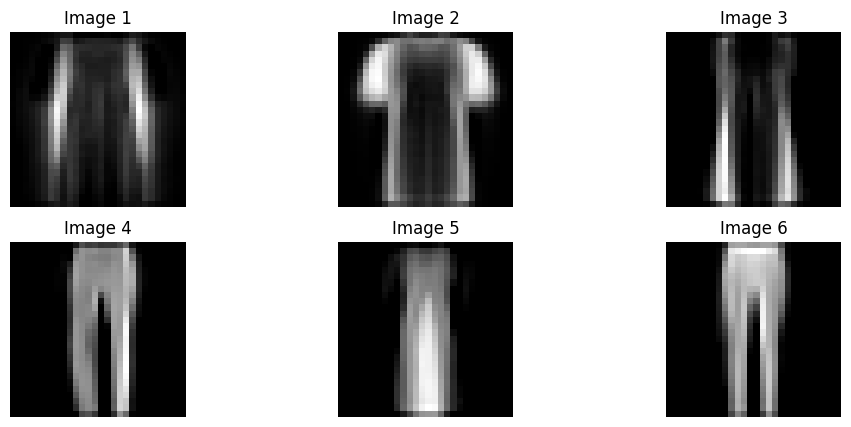

In [13]:
 mynmf=MyNMF(6)
 mynmf.fit_transform(X)
 display_image(mynmf.components)

2. Choisissez une image dans nos données. Affichez là avec ses compressions (projection puis reconstruction) après une NMF avec $i$ composantes, pour $i$ prenant les valeurs 3, 5, 10, 50 et 100.

n_components=3
n_components=5
n_components=10
n_components=50
n_components=100


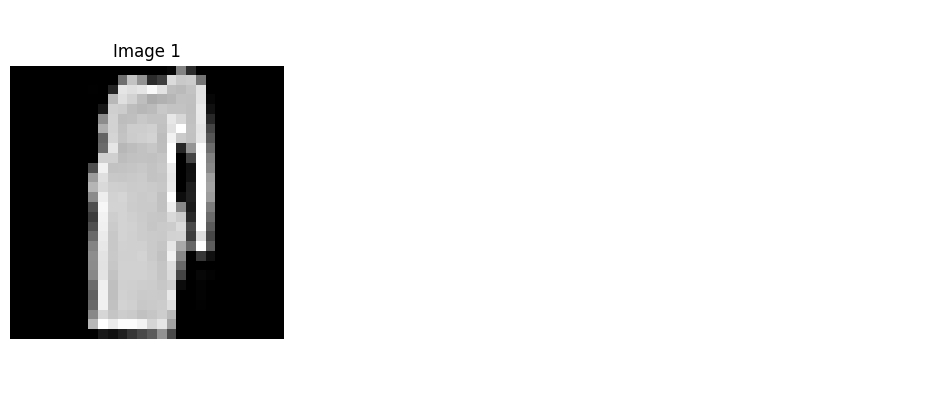

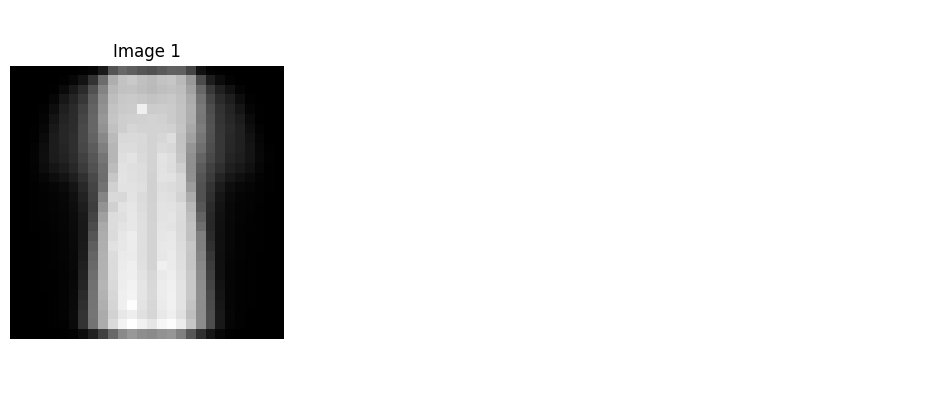

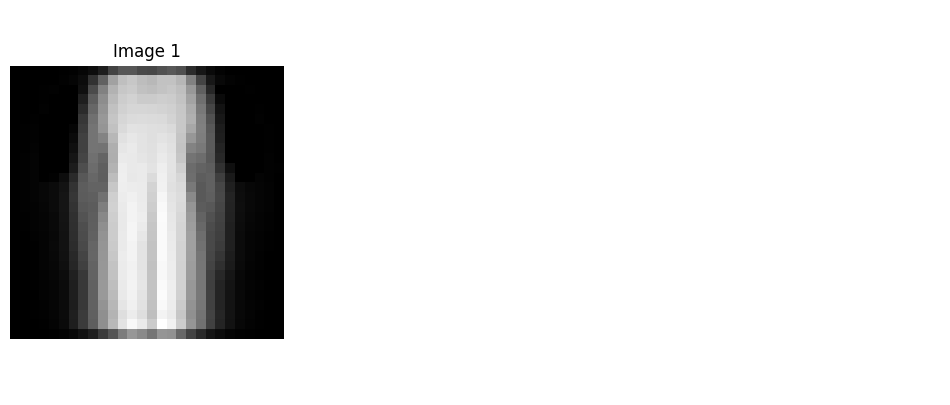

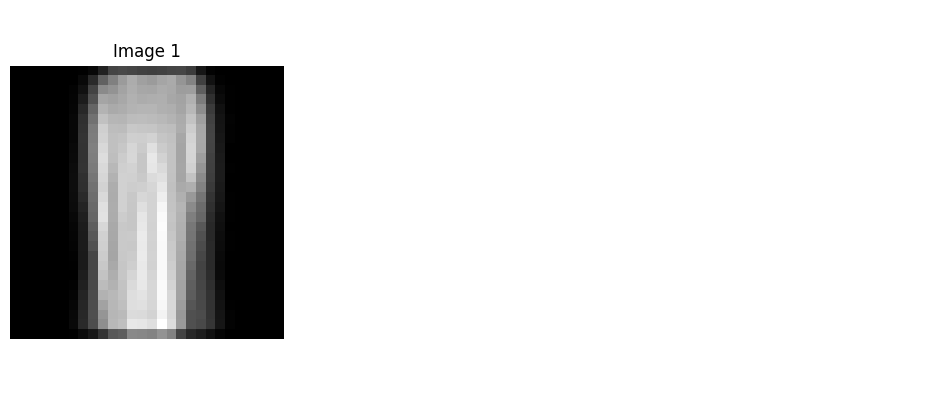

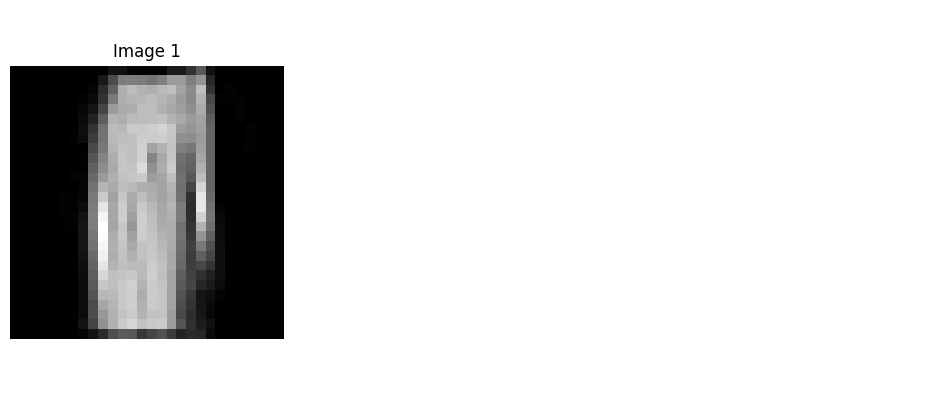

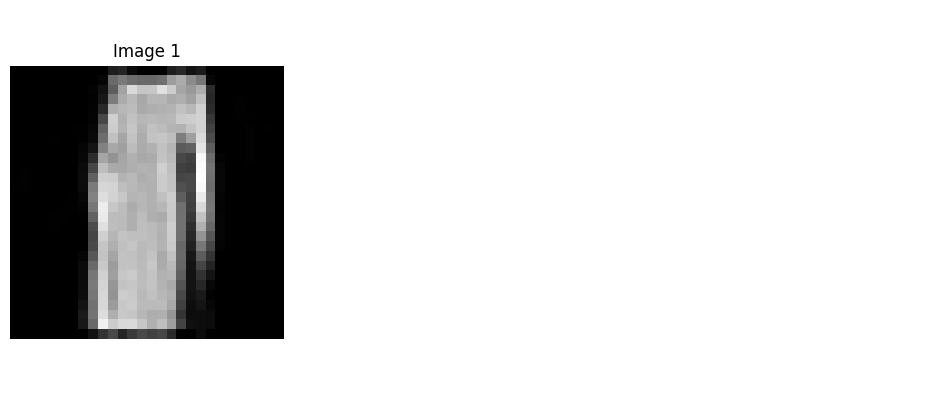

In [ ]:
rnd=np.random.randint(0,X.shape[0])
img=X[rnd]
display_image(img)
cmpsnt=[3,5,10,50,100]
for i in cmpsnt:
    print(f"n_components={i}")
    mynmf=MyNMF(n_components=i)
    W=mynmf.fit_transform(X)
    w_rnd=W[rnd]
    display_image(mynmf.inverse_transform(w_rnd.reshape(1,-1)).flatten())

2. Faites la même chose avec une PCA.

n_components=3
n_components=5
n_components=10
n_components=50
n_components=100


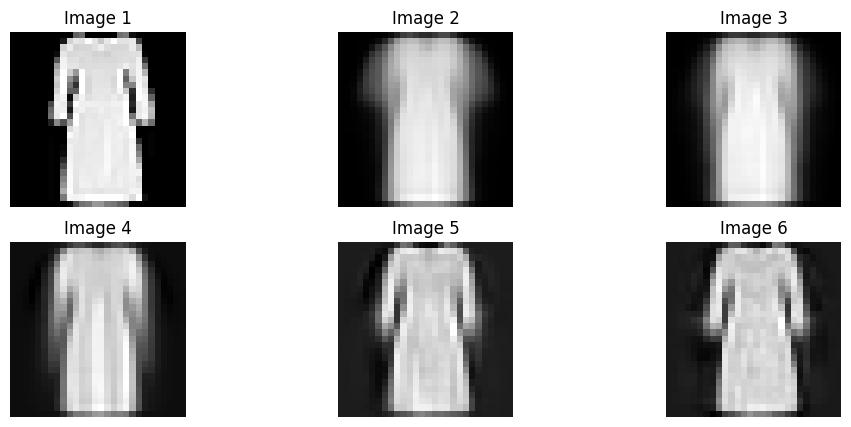

In [46]:
rnd=np.random.randint(0,X.shape[0])
img=[X[rnd]]

cmpsnt=[3,5,10,50,100]
for i in cmpsnt:
    print(f"n_components={i}")
    pca=PCA(n_components=i)
    W=pca.fit_transform(X)
    w_rnd=W[rnd]
    img.append(pca.inverse_transform(w_rnd.reshape(1,-1)).flatten())
display_image(img)

## Exercice 6

1. Utilisez la classe `MyNMF` pour projeter `X` sur deux dimensions. Visualisez le résultat dans un nuage de points avec `plt.scatter` (**[documentation](https://matplotlib.org/stable/api/_as_gen/matplotlib.pyplot.scatter.html#matplotlib.pyplot.scatter)**).

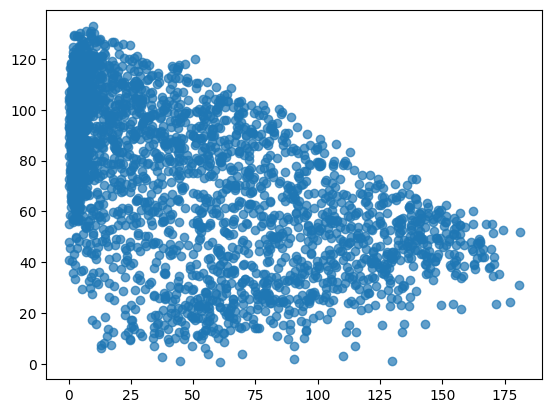

In [33]:
mymnf=MyNMF(2)
mymnf.fit_transform(X)
W=mymnf.transform(X)
plt.scatter(W[:,0],W[:,1],alpha=0.7)

2. Dans ce nuage de points, colorez chaque point en fonction de son véritable label (le vecteur de labels est `y`).

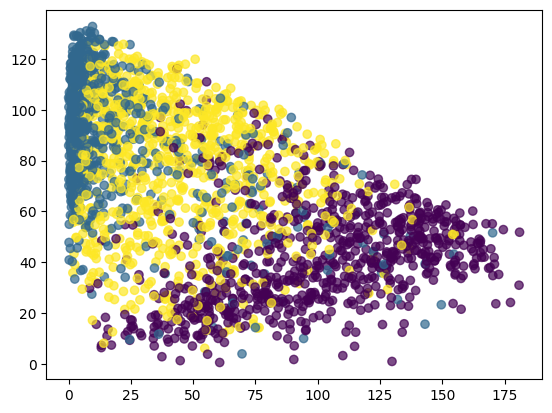

In [34]:
plt.scatter(W[:,0],W[:,1],c=y,alpha=0.7)

3. Changez la couleur des points pour qu'ils soient colorés en fonction de leur classification par un K-clustering de `X` avec 3 clusters. Affichez les images correspondants aux centroïdes. Affichez également la précision des labels obtenus.

Accuracy KMeans: 0.5747534516765286


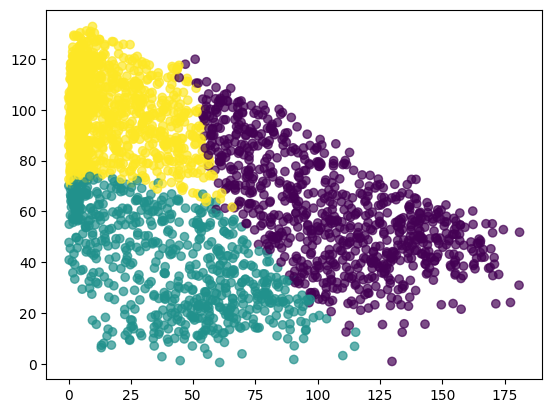

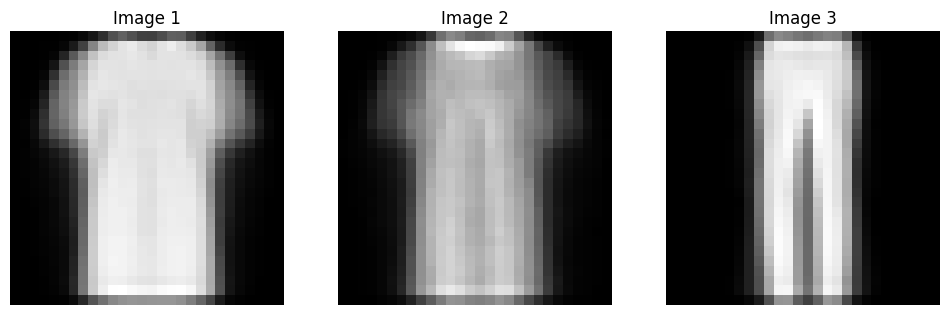

In [35]:
km=KMeans(3)
km.fit(X)
print("Accuracy KMeans:",accuracy(km.labels_))
plt.scatter(W[:,0],W[:,1],c=km.labels_,alpha=0.7)
display_image(km.cluster_centers_)

4. Enfin, changez la couleur des points pour qu'ils soient colorés en fonction de leur classification par un K-clustering de la projection NMF de `X` en 2 dimensions, avec 3 clusters. Affichez les images correspondants aux centroïdes ainsi que la précision des labels obtenus.

Accuracy km: 0.6201183431952663


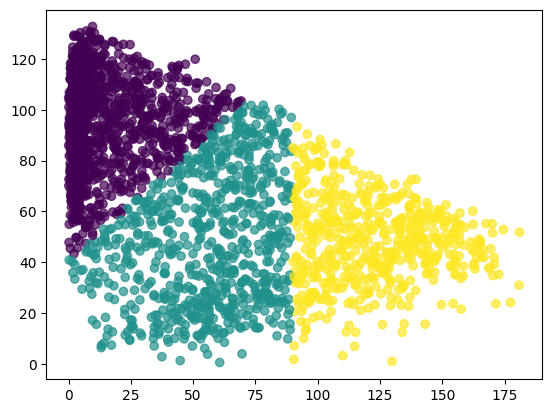

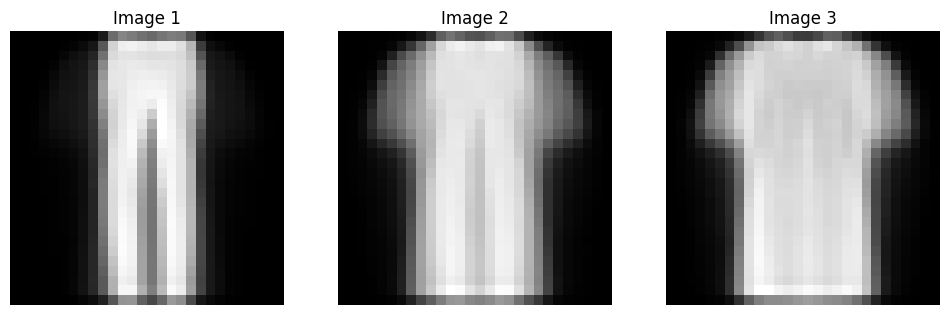

In [39]:
km=KMeans(3)
km.fit(W)
print("Accuracy km:",accuracy(km.labels_))
plt.scatter(W[:,0],W[:,1],c=km.labels_,alpha=0.7)

display_image(km.cluster_centers_ @ mymnf.components)


## Exercice 7

1. Dessinez un graphe calculant la précision (`accuracy`) des labels obtenus par un K-clusterings de la projection NMF de `X` avec $i$ composantes avec 3 clusters, pour $i$ allant de 5 à 40 avec un pas de 5. Utilisez `plt.plot`. Faites le plusieurs fois, pour voir les différents minima locaux obtenus par optimisation. 

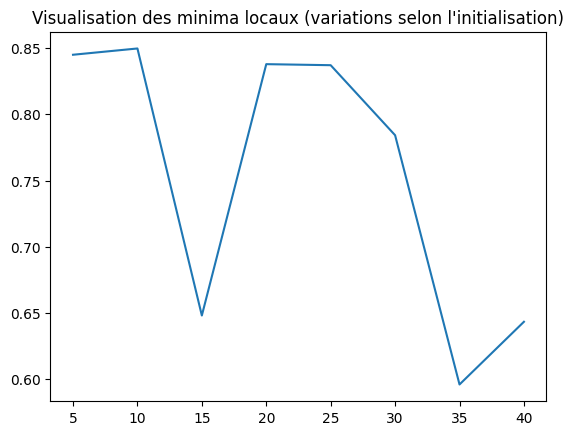

In [45]:
km=KMeans(n_clusters=3)

accuracies=[]
for i in range(5,45,5):
    mynfm=MyNMF(n_components=i)
    mynfm.fit_transform(X)
    W=mynfm.transform(X)
    km.fit(W)
    accuracies.append(accuracy(km.labels_))
 
plt.plot(range(5,45,5),accuracies)

plt.title("Visualisation des minima locaux (variations selon l'initialisation)")
plt.show()

2. Faîtes la même chose mais avec 20 clusters.

Text(0.5, 1.0, "Visualisation des minima locaux (variations selon l'initialisation)")

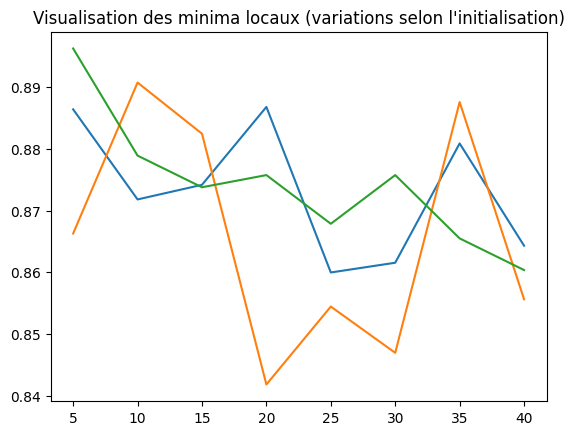

In [47]:
km=KMeans(n_clusters=20)
for j in range(3):
 accuracies=[]
 for i in range(5,45,5):
    mynfm=MyNMF(n_components=i)
    W=mynfm.fit_transform(X)
    km.fit(W)
    accuracies.append(accuracy(km.labels_))
 plt.plot(range(5,45,5),accuracies,label=f"run{j+1}")

plt.title("Visualisation des minima locaux (variations selon l'initialisation)")

3. Comment interprétez-vous les résultats ?


# Exercice 8

À l'aune de tous ces résultats, quelles différences faites vous entre la NMF et la PCA dans le cadre de notre analyse de données ?